# Implement Knowledge Distillation

**Difficulty**: 🟡 Medium

**Companies**: Google, Apple, Meta, Qualcomm, Tesla

---

### Problem Statement

**Knowledge Distillation** is a model compression technique where a small "student" model learns to mimic a large "teacher" model's behavior. Instead of training only on hard labels (one-hot), the student also learns from the teacher's **soft predictions** (probability distributions over classes), which contain richer information about inter-class relationships.

The key insight: a teacher's soft predictions like `[0.7, 0.2, 0.1]` carry more information than hard labels `[1, 0, 0]` because they reveal which classes the teacher considers similar.

Your task is to implement the distillation loss, train a teacher, distill to a student, and compare against a student trained with hard labels only.

---

### Requirements

1. **Distillation Loss** — Combine KL divergence on temperature-softened outputs with cross-entropy on hard labels, controlled by weight `alpha`.
2. **Teacher Model** — A large MLP trained on the classification task.
3. **Student Model** — A small MLP (fewer layers/neurons) trained via distillation.
4. **Comparison** — Student-distilled vs. student-hard-only vs. teacher accuracies.

---

### Constraints

- ✅ Use PyTorch for all implementations.
- ✅ Use synthetic classification data (e.g., from scikit-learn) for tractability.
- ✅ Temperature `T` should soften the logits: `softmax(logits / T)`.
- ✅ The distillation loss must be: `alpha * T^2 * KL_div(student_soft, teacher_soft) + (1 - alpha) * CE(student_logits, hard_labels)`.
- ❌ Do **not** use any pre-built distillation libraries.

---

<details>
  <summary>💡 Hint</summary>

  - Use `F.kl_div(input, target, reduction='batchmean')` where `input = F.log_softmax(student_logits / T, dim=-1)` and `target = F.softmax(teacher_logits / T, dim=-1)`.
  - The `T^2` factor compensates for the gradient magnitude change when using temperature scaling.
  - A good temperature is typically 3-5. Higher temperature produces softer distributions.
  - A good alpha is 0.5-0.9, giving more weight to the soft teacher knowledge.
  - Make sure the teacher is in `eval()` mode and its outputs are detached during distillation.

</details>

---

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

In [2]:
# Generate synthetic classification data
torch.manual_seed(42)
np.random.seed(42)

n_classes = 6
n_features = 20
n_samples = 5000

X, y = make_classification(
    n_samples=n_samples, n_features=n_features, n_informative=15,
    n_redundant=3, n_classes=n_classes, n_clusters_per_class=2,
    random_state=42
)

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Classes: {n_classes}, Features: {n_features}')
print(f'Class distribution (train): {torch.bincount(y_train).tolist()}')

Train: torch.Size([4000, 20]), Test: torch.Size([1000, 20])
Classes: 6, Features: 20
Class distribution (train): [657, 654, 671, 661, 683, 674]


In [ ]:
# --- Part 1: Distillation Loss ---

def distillation_loss(student_logits, teacher_logits, labels, temperature, alpha):
    """
    Compute the knowledge distillation loss.

    Loss = alpha * T^2 * KL(student_soft || teacher_soft) + (1 - alpha) * CE(student, labels)

    Args:
        student_logits (Tensor): Raw logits from student model, shape (B, C).
        teacher_logits (Tensor): Raw logits from teacher model, shape (B, C). Should be detached.
        labels (Tensor): Ground truth labels, shape (B,).
        temperature (float): Temperature for softening distributions (T > 1 makes softer).
        alpha (float): Weight for soft loss vs hard loss. alpha=1 means only soft loss.

    Returns:
        loss (Tensor): Combined distillation loss.
    """
    # TODO: Compute soft loss (KL divergence between temperature-scaled distributions)
    # student_soft = F.log_softmax(student_logits / temperature, dim=-1)
    # teacher_soft = F.softmax(teacher_logits / temperature, dim=-1)
    # soft_loss = F.kl_div(student_soft, teacher_soft, reduction='batchmean')

    # TODO: Compute hard loss (standard cross-entropy with true labels)
    # hard_loss = F.cross_entropy(student_logits, labels)

    # TODO: Combine: alpha * T^2 * soft_loss + (1 - alpha) * hard_loss
    student_soft = F.log_softmax(student_logits / temperature, dim=-1)
    teacher_soft = F.softmax(teacher_logits / temperature, dim=-1)
    soft_loss = F.kl_div(student_soft, teacher_soft, reduction='batchmean')

    hard_loss = F.cross_entropy(student_logits, labels)
    return alpha * temperature ** 2 * soft_loss + (1 - alpha) * hard_loss


# Quick test
test_student = torch.randn(4, n_classes)
test_teacher = torch.randn(4, n_classes)
test_labels = torch.tensor([0, 1, 2, 3])
test_loss = distillation_loss(test_student, test_teacher.detach(), test_labels, temperature=4.0, alpha=0.7)
print(f'Test distillation loss: {test_loss.item():.4f}')

softloss = 0.05237763747572899, hard loss = 1.8982475996017456
Test distillation loss: 1.1561


In [7]:
# --- Part 2: Teacher and Student Models ---

class TeacherModel(nn.Module):
    """Large MLP for classification (the teacher)."""
    def __init__(self, input_dim, n_classes, hidden_dim=256, n_layers=4):
        super().__init__()
        layers = [nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.BatchNorm1d(hidden_dim)]
        for _ in range(n_layers - 1):
            layers.extend([nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), nn.BatchNorm1d(hidden_dim)])
        layers.append(nn.Linear(hidden_dim, n_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class StudentModel(nn.Module):
    """Small MLP for classification (the student)."""
    def __init__(self, input_dim, n_classes, hidden_dim=64, n_layers=2):
        super().__init__()
        layers = [nn.Linear(input_dim, hidden_dim), nn.ReLU()]
        for _ in range(n_layers - 1):
            layers.extend([nn.Linear(hidden_dim, hidden_dim), nn.ReLU()])
        layers.append(nn.Linear(hidden_dim, n_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


teacher = TeacherModel(n_features, n_classes, hidden_dim=256, n_layers=4)
student_distill = StudentModel(n_features, n_classes, hidden_dim=64, n_layers=2)
student_hard = StudentModel(n_features, n_classes, hidden_dim=64, n_layers=2)

print(f'Teacher parameters: {sum(p.numel() for p in teacher.parameters()):,}')
print(f'Student parameters: {sum(p.numel() for p in student_distill.parameters()):,}')
print(f'Compression ratio: {sum(p.numel() for p in teacher.parameters()) / sum(p.numel() for p in student_distill.parameters()):.1f}x')

Teacher parameters: 206,342
Student parameters: 5,894
Compression ratio: 35.0x


In [8]:
# --- Part 3: Train Teacher ---

def train_with_hard_labels(model, X_train, y_train, n_epochs=100, batch_size=128, lr=1e-3):
    """Train a model with standard cross-entropy loss."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []

    model.train()
    for epoch in range(n_epochs):
        perm = torch.randperm(len(X_train))
        epoch_loss = 0
        n_batches = 0

        for i in range(0, len(X_train), batch_size):
            x = X_train[perm[i:i+batch_size]]
            y = y_train[perm[i:i+batch_size]]

            logits = model(x)
            loss = F.cross_entropy(logits, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            n_batches += 1

        losses.append(epoch_loss / n_batches)
        if (epoch + 1) % 25 == 0:
            print(f'  Epoch {epoch+1}/{n_epochs}, Loss: {losses[-1]:.4f}')

    return losses


print('Training Teacher...')
teacher_losses = train_with_hard_labels(teacher, X_train, y_train, n_epochs=100)

Training Teacher...
  Epoch 25/100, Loss: 0.0706
  Epoch 50/100, Loss: 0.0181
  Epoch 75/100, Loss: 0.0082
  Epoch 100/100, Loss: 0.0213


In [9]:
# --- Part 4: Train Student with Hard Labels Only ---

print('Training Student (hard labels only)...')
student_hard_losses = train_with_hard_labels(student_hard, X_train, y_train, n_epochs=100)

Training Student (hard labels only)...
  Epoch 25/100, Loss: 0.3494
  Epoch 50/100, Loss: 0.2016
  Epoch 75/100, Loss: 0.1118
  Epoch 100/100, Loss: 0.0622


In [10]:
# --- Part 5: Train Student with Knowledge Distillation ---

def train_with_distillation(student, teacher, X_train, y_train,
                            temperature=4.0, alpha=0.7, n_epochs=100,
                            batch_size=128, lr=1e-3):
    """
    Train student using knowledge distillation from teacher.

    Args:
        student: Student model to train.
        teacher: Pre-trained teacher model (frozen).
        temperature: Softening temperature.
        alpha: Weight for soft loss.
    """
    optimizer = torch.optim.Adam(student.parameters(), lr=lr)
    losses = []

    teacher.eval()  # Teacher is frozen
    student.train()

    for epoch in range(n_epochs):
        perm = torch.randperm(len(X_train))
        epoch_loss = 0
        n_batches = 0

        for i in range(0, len(X_train), batch_size):
            x = X_train[perm[i:i+batch_size]]
            y = y_train[perm[i:i+batch_size]]

            # Get teacher predictions (no gradient)
            with torch.no_grad():
                teacher_logits = teacher(x)

            # Get student predictions
            student_logits = student(x)

            # Compute distillation loss
            loss = distillation_loss(student_logits, teacher_logits, y, temperature, alpha)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            n_batches += 1

        losses.append(epoch_loss / n_batches)
        if (epoch + 1) % 25 == 0:
            print(f'  Epoch {epoch+1}/{n_epochs}, Loss: {losses[-1]:.4f}')

    return losses


print('Training Student (with distillation)...')
student_distill_losses = train_with_distillation(
    student_distill, teacher, X_train, y_train,
    temperature=4.0, alpha=0.7, n_epochs=100
)

Training Student (with distillation)...
softloss = 1.2575761079788208, hard loss = 1.8604375123977661
softloss = 1.2365964651107788, hard loss = 1.8203463554382324
softloss = 1.1743263006210327, hard loss = 1.8094642162322998
softloss = 1.1879712343215942, hard loss = 1.8033310174942017
softloss = 1.209682822227478, hard loss = 1.8061835765838623
softloss = 1.256442904472351, hard loss = 1.7436301708221436
softloss = 1.240208387374878, hard loss = 1.727696180343628
softloss = 1.19900643825531, hard loss = 1.7384015321731567
softloss = 1.2085679769515991, hard loss = 1.7726871967315674
softloss = 1.2289397716522217, hard loss = 1.752934455871582
softloss = 1.1940968036651611, hard loss = 1.719608187675476
softloss = 1.1725730895996094, hard loss = 1.673895001411438
softloss = 1.2064889669418335, hard loss = 1.745118498802185
softloss = 1.207502841949463, hard loss = 1.6463019847869873
softloss = 1.1943870782852173, hard loss = 1.6338415145874023
softloss = 1.2170213460922241, hard loss 

=== Results ===
Teacher Accuracy:              0.8590
Student (hard labels only):    0.8350
Student (distilled):           0.8350
Distillation improvement:      +0.0000


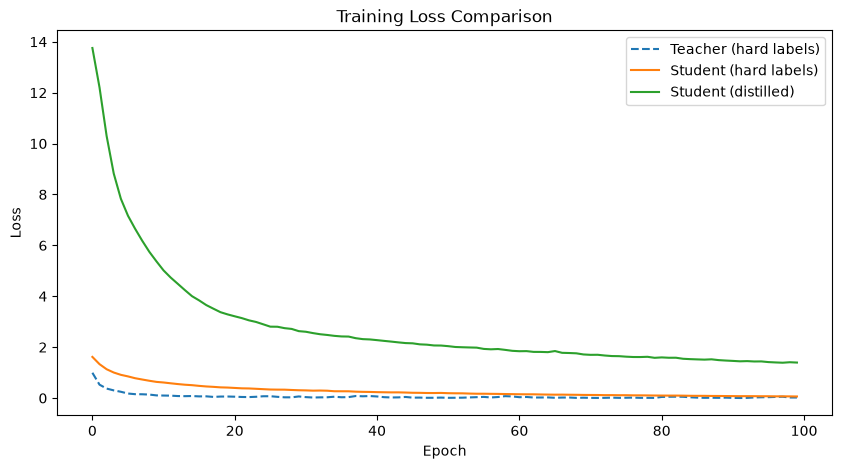

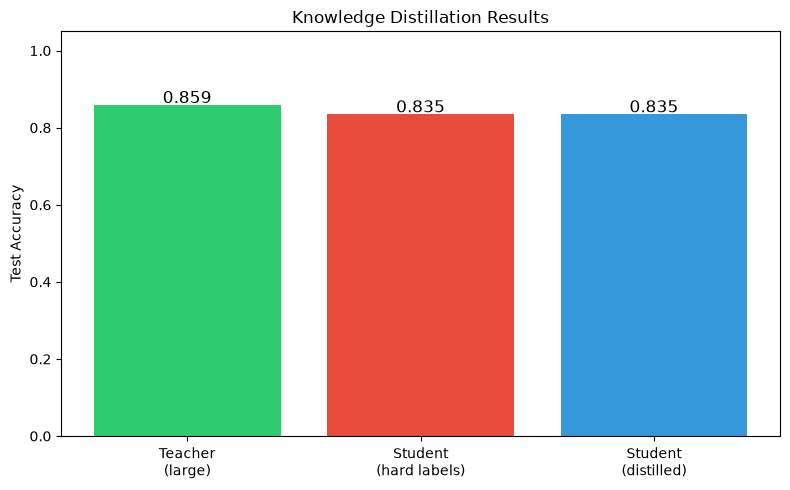


=== Validation ===
PASSED: Teacher achieves reasonable accuracy (0.8590)
PASSED: Distilled student (0.8350) performs well vs hard-only (0.8350)

All validations passed!


In [11]:
# --- Validation ---

def evaluate(model, X_test, y_test):
    model.eval()
    with torch.no_grad():
        logits = model(X_test)
        preds = logits.argmax(dim=-1)
        accuracy = (preds == y_test).float().mean().item()
    return accuracy


teacher_acc = evaluate(teacher, X_test, y_test)
student_hard_acc = evaluate(student_hard, X_test, y_test)
student_distill_acc = evaluate(student_distill, X_test, y_test)

print('=== Results ===')
print(f'Teacher Accuracy:              {teacher_acc:.4f}')
print(f'Student (hard labels only):    {student_hard_acc:.4f}')
print(f'Student (distilled):           {student_distill_acc:.4f}')
print(f'Distillation improvement:      {student_distill_acc - student_hard_acc:+.4f}')

# Plot training curves
plt.figure(figsize=(10, 5))
plt.plot(teacher_losses, label='Teacher (hard labels)', linestyle='--')
plt.plot(student_hard_losses, label='Student (hard labels)')
plt.plot(student_distill_losses, label='Student (distilled)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Comparison')
plt.legend()
plt.show()

# Bar chart of accuracies
fig, ax = plt.subplots(figsize=(8, 5))
models = ['Teacher\n(large)', 'Student\n(hard labels)', 'Student\n(distilled)']
accs = [teacher_acc, student_hard_acc, student_distill_acc]
colors = ['#2ecc71', '#e74c3c', '#3498db']
bars = ax.bar(models, accs, color=colors)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{acc:.3f}', ha='center', fontsize=12)
ax.set_ylabel('Test Accuracy')
ax.set_title('Knowledge Distillation Results')
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

# Checks
print('\n=== Validation ===')
assert teacher_acc > 0.5, f'Teacher accuracy too low: {teacher_acc:.4f}'
print(f'PASSED: Teacher achieves reasonable accuracy ({teacher_acc:.4f})')

assert student_distill_acc > student_hard_acc - 0.05, (
    f'Distilled student ({student_distill_acc:.4f}) should be comparable or better '
    f'than hard-label student ({student_hard_acc:.4f})'
)
print(f'PASSED: Distilled student ({student_distill_acc:.4f}) performs well vs hard-only ({student_hard_acc:.4f})')

print('\nAll validations passed!')